# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [1]:
import sys

import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(100, None, None, model, testing=True)

epoch 0; train: loss 462.78656005859375; val: loss 432.49432373046875
epoch 1; train: loss 358.4572448730469; val: loss 427.2412414550781
epoch 2; train: loss 317.13348388671875; val: loss 412.03399658203125
epoch 3; train: loss 257.64990234375; val: loss 386.86053466796875
epoch 4; train: loss 207.02561950683594; val: loss 348.64459228515625
epoch 5; train: loss 167.98146057128906; val: loss 299.8702392578125
epoch 6; train: loss 143.72181701660156; val: loss 245.2824249267578
epoch 7; train: loss 118.00495147705078; val: loss 197.20440673828125
epoch 8; train: loss 100.10074615478516; val: loss 159.16238403320312
epoch 9; train: loss 83.61038208007812; val: loss 131.5719451904297
epoch 10; train: loss 69.60845184326172; val: loss 113.38990783691406
epoch 11; train: loss 58.81157302856445; val: loss 101.56983947753906
epoch 12; train: loss 51.08052062988281; val: loss 90.9693832397461
epoch 13; train: loss 44.72175216674805; val: loss 79.03244018554688
epoch 14; train: loss 39.2840881

As can be seen above, the basic implementation of the training loop works, decreasing the loss significantly over the epochs. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [5]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")
img, ann = data[1]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

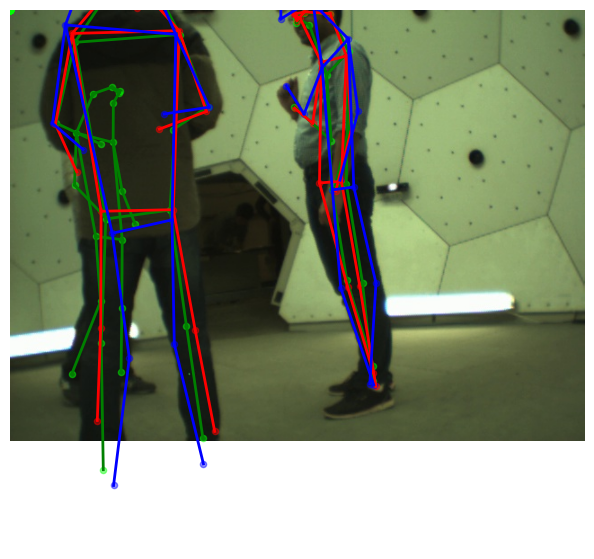

In [6]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.